In [1]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
from tensorflow.keras.callbacks import EarlyStopping

# Path to the bird sound folder and output folder
audio_folder = '/Users/adi/Classification/Voice of Birds'  # Folder with sub folders for each species
output_folder = '/Users/adi/Classification/spectrograms'  # Folder to save the spectrogram images

# Parameters for resizing images
image_height = 128  # Resize dimensions
image_width = 128
num_samples_per_species = 10

# Ensure the output folder exists
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Loop through each species folder in the audio folder
for species_index, species in enumerate(os.listdir(audio_folder)):
    species_path = os.path.join(audio_folder, species)

    # Check if it's a directory (a species folder)
    if os.path.isdir(species_path):
        print(f"Processing species folder: {species}")

        # Create an output folder for the species' spectrograms
        species_output_path = os.path.join(output_folder, species)
        if not os.path.exists(species_output_path):
            os.makedirs(species_output_path)

        # Get a list of all audio files in the species folder
        audio_files = [f for f in os.listdir(species_path) if f.endswith('.mp3')]

        # Sample a subset of audio files if there are more than the desired number of samples
        sampled_audio_files = random.sample(audio_files, min(len(audio_files), num_samples_per_species))

        # Loop through each sampled audio file in the species folder
        for audio_file in sampled_audio_files:
            audio_file_path = os.path.join(species_path, audio_file)

            print(f"Processing {audio_file_path}...")

            try:
                # Load the audio file using librosa 
                y, sr = librosa.load(audio_file_path, sr=None)  # None to keep original sample rate

                # Generate the mel spectrogram
                S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
                S_db = librosa.power_to_db(S, ref=np.max)

                # Check if the spectrogram array is valid
                if S_db.size == 0 or np.isnan(S_db).any():
                    print(f"Invalid spectrogram for {audio_file}. Skipping...")
                    continue

                # Resize the spectrogram to the desired size for CNN input
                spectrogram_resized = cv2.resize(S_db, (image_width, image_height))

                # Save the resized spectrogram as an image (PNG)
                spectrogram_filename = os.path.splitext(audio_file)[0] + '_resized.png'
                spectrogram_filepath = os.path.join(species_output_path, spectrogram_filename)

                # Save the spectrogram as an image
                plt.figure(figsize=(10, 4))
                librosa.display.specshow(spectrogram_resized, x_axis='time', y_axis='mel', sr=sr)
                plt.colorbar(format='%+2.0f dB')
                plt.title(f"Spectrogram of {audio_file}")
                plt.savefig(spectrogram_filepath)
                plt.close()

                print(f"Spectrogram saved as {spectrogram_filepath}")
            except Exception as e:
                print(f"Error processing {audio_file_path}: {e}")

print("Spectrogram generation and saving completed!")


Processing species folder: Moluccan Megapode_sound
Processing /Users/adi/Classification/Voice of Birds/Moluccan Megapode_sound/Moluccan Megapode7.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Moluccan Megapode_sound/Moluccan Megapode7_resized.png
Processing /Users/adi/Classification/Voice of Birds/Moluccan Megapode_sound/Moluccan Megapode3.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Moluccan Megapode_sound/Moluccan Megapode3_resized.png
Processing /Users/adi/Classification/Voice of Birds/Moluccan Megapode_sound/Moluccan Megapode5.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Moluccan Megapode_sound/Moluccan Megapode5_resized.png
Processing /Users/adi/Classification/Voice of Birds/Moluccan Megapode_sound/Moluccan Megapode2.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Moluccan Megapode_sound/Moluccan Megapode2_resized.png
Processing /Users/adi/Classification/Voice of Birds/Moluccan Megapode_sound/Moluc

/opt/anaconda3/lib/python3.12/site-packages/librosa/feature/spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


Spectrogram saved as /Users/adi/Classification/spectrograms/Little Tinamou_sound/Little Tinamou6_resized.png
Processing /Users/adi/Classification/Voice of Birds/Little Tinamou_sound/Little Tinamou4.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Little Tinamou_sound/Little Tinamou4_resized.png
Processing /Users/adi/Classification/Voice of Birds/Little Tinamou_sound/Little Tinamou5.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Little Tinamou_sound/Little Tinamou5_resized.png
Processing /Users/adi/Classification/Voice of Birds/Little Tinamou_sound/Little Tinamou24.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Little Tinamou_sound/Little Tinamou24_resized.png
Processing /Users/adi/Classification/Voice of Birds/Little Tinamou_sound/Little Tinamou21.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Little Tinamou_sound/Little Tinamou21_resized.png
Processing /Users/adi/Classification/Voice of Birds/Little Tinamou_

Spectrogram saved as /Users/adi/Classification/spectrograms/Chestnut-bellied Guan_sound/Chestnut-bellied Guan2_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chestnut-bellied Guan_sound/Chestnut-bellied Guan8.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chestnut-bellied Guan_sound/Chestnut-bellied Guan8_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chestnut-bellied Guan_sound/Chestnut-bellied Guan11.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chestnut-bellied Guan_sound/Chestnut-bellied Guan11_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chestnut-bellied Guan_sound/Chestnut-bellied Guan3.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chestnut-bellied Guan_sound/Chestnut-bellied Guan3_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chestnut-bellied Guan_sound/Chestnut-bellied Guan6.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chestn

Spectrogram saved as /Users/adi/Classification/spectrograms/Red-legged Tinamou_sound/Red-legged Tinamou26_resized.png
Processing /Users/adi/Classification/Voice of Birds/Red-legged Tinamou_sound/Red-legged Tinamou21.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Red-legged Tinamou_sound/Red-legged Tinamou21_resized.png
Processing /Users/adi/Classification/Voice of Birds/Red-legged Tinamou_sound/Red-legged Tinamou3.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Red-legged Tinamou_sound/Red-legged Tinamou3_resized.png
Processing /Users/adi/Classification/Voice of Birds/Red-legged Tinamou_sound/Red-legged Tinamou13.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Red-legged Tinamou_sound/Red-legged Tinamou13_resized.png
Processing /Users/adi/Classification/Voice of Birds/Red-legged Tinamou_sound/Red-legged Tinamou23.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Red-legged Tinamou_sound/Red-legged Tinamou23_resi

...

Note: Illegal Audio-MPEG-Header 0x7370616e at offset 344524.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Spectrogram saved as /Users/adi/Classification/spectrograms/Chaco Chachalaca_sound/Chaco Chachalaca14_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chaco Chachalaca_sound/Chaco Chachalaca10.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chaco Chachalaca_sound/Chaco Chachalaca10_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chaco Chachalaca_sound/Chaco Chachalaca6.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chaco Chachalaca_sound/Chaco Chachalaca6_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chaco Chachalaca_sound/Chaco Chachalaca3.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chaco Chachalaca_sound/Chaco Chachalaca3_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chaco Chachalaca_sound/Chaco Chachalaca24.mp3...


Note: Illegal Audio-MPEG-Header 0x7370616e at offset 344524.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Spectrogram saved as /Users/adi/Classification/spectrograms/Chaco Chachalaca_sound/Chaco Chachalaca24_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chaco Chachalaca_sound/Chaco Chachalaca16.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chaco Chachalaca_sound/Chaco Chachalaca16_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chaco Chachalaca_sound/Chaco Chachalaca20.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chaco Chachalaca_sound/Chaco Chachalaca20_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chaco Chachalaca_sound/Chaco Chachalaca11.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chaco Chachalaca_sound/Chaco Chachalaca11_resized.png
Processing /Users/adi/Classification/Voice of Birds/Chaco Chachalaca_sound/Chaco Chachalaca15.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Chaco Chachalaca_sound/Chaco Chachalaca15_resized.png
Processing species folder:

Spectrogram saved as /Users/adi/Classification/spectrograms/Quebracho Crested Tinamou_sound/Quebracho Crested Tinamou6_resized.png
Processing /Users/adi/Classification/Voice of Birds/Quebracho Crested Tinamou_sound/Quebracho Crested Tinamou7.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Quebracho Crested Tinamou_sound/Quebracho Crested Tinamou7_resized.png
Processing species folder: Rusty Tinamou_sound
Processing /Users/adi/Classification/Voice of Birds/Rusty Tinamou_sound/Rusty Tinamou6.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Rusty Tinamou_sound/Rusty Tinamou6_resized.png
Processing /Users/adi/Classification/Voice of Birds/Rusty Tinamou_sound/Rusty Tinamou4.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Rusty Tinamou_sound/Rusty Tinamou4_resized.png
Processing /Users/adi/Classification/Voice of Birds/Rusty Tinamou_sound/Rusty Tinamou13.mp3...
Spectrogram saved as /Users/adi/Classification/spectrograms/Rusty Tinamou_so

In [2]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Parameters for resizing images
image_height = 128
image_width = 128
num_samples_per_species = 10

# Path to the spectrograms folder
output_folder = '/Users/adi/Classification/spectrograms'

# Lists to store the spectrogram images and labels
spectrogram_images = []
labels = []

# Loop through each species folder in the output folder
for species_index, species in enumerate(os.listdir(output_folder)):
    species_path = os.path.join(output_folder, species)

    # Check (species folder)
    if os.path.isdir(species_path):
        print(f"Processing species folder: {species}")

        # Get list spectrogram images
        spectrogram_files = [f for f in os.listdir(species_path) if f.endswith('.png')]

        # Loop through each spectrogram image in the species folder
        for spectrogram_file in spectrogram_files:
            spectrogram_file_path = os.path.join(species_path, spectrogram_file)

            try:
                # Read the spectrogram image using  (grayscale mode)
                image = cv2.imread(spectrogram_file_path, cv2.IMREAD_GRAYSCALE)

                # Resize the image to the desired shape 
                image_resized = cv2.resize(image, (image_width, image_height))

                # Append the resized image and corresponding label 
                spectrogram_images.append(image_resized)
                labels.append(species_index)  # The label is the index of the species folder

            except Exception as e:
                print(f"Error processing {spectrogram_file_path}: {e}")

# Convert the spectrogram images to  [0, 1]
X = np.array(spectrogram_images)
X = np.expand_dims(X, axis=-1)  # Add  (grayscale)
X = X / 255.0  # Normalize to [0, 1]


y = np.array(labels)
y = to_categorical(y)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")


Processing species folder: Moluccan Megapode_sound
Processing species folder: Micronesian Megapode_sound
Processing species folder: Andean Tinamou_sound
Processing species folder: Wattled Brushturkey_sound
Processing species folder: Red-billed Brushturkey_sound
Processing species folder: Little Tinamou_sound
Processing species folder: Speckled Chachalaca_sound
Processing species folder: Somali Ostrich_sound
Processing species folder: Chestnut-bellied Guan_sound
Processing species folder: Spixs Guan_sound
Processing species folder: Rusty-margined Guan_sound
Processing species folder: Great Spotted Kiwi_sound
Processing species folder: Brushland Tinamou_sound
Processing species folder: Huayco Tinamou_sound
Processing species folder: Vanuatu Megapode_sound
Processing species folder: Darwins Nothura_sound
Processing species folder: Choco Tinamou_sound
Processing species folder: Tanimbar Megapode_sound
Processing species folder: Lesser Rhea_sound
Processing species folder: Red-legged Tinamo

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# number of classes 
num_classes = 114  #  number of species in your dataset

# Build the CNN model
model = Sequential()

# Input layer
model.add(Input(shape=(image_height, image_width, 1)))  

# Convolutional layer 1 with BatchNormalization
model.add(Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional layer 2 with BatchNormalization
model.add(Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional layer 3 with BatchNormalization
model.add(Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Additional convolutional layers for increased depth
model.add(Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten and dense layers
model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.5))  # Dropout layer for regularization

# Output layer
model.add(Dense(num_classes, activation='softmax'))

# Compile the model r
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Training the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 114)            │        14,706 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,584,242 (6.04 MB)

 Trainable params: 1,583,282 (6.04 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 263ms/step - accuracy: 0.0122 - loss: 10.9260 - val_accuracy: 0.0102 - val_loss: 10.1745
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.0068 - loss: 10.1172 - val_accuracy: 0.0102 - val_loss: 10.0991
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - accuracy: 0.0124 - loss: 9.9547 - val_accuracy: 0.0102 - val_loss: 10.0223
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 0.0271 - loss: 9.7473 - val_accuracy: 0.0102 - val_loss: 9.9535
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step - accuracy: 0.0197 - loss: 9.6149 - val_accuracy: 0.0204 - val_loss: 9.8815
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.0407 - loss: 9.3845 - val_accuracy: 0.0153 - val_loss: 9.8066
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 245ms/step - accuracy: 0.0282 - loss: 9.2270 - val_accuracy: 0.0102 - val_loss: 9.6953
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.0416 - loss: 8.9760 - val_accurac

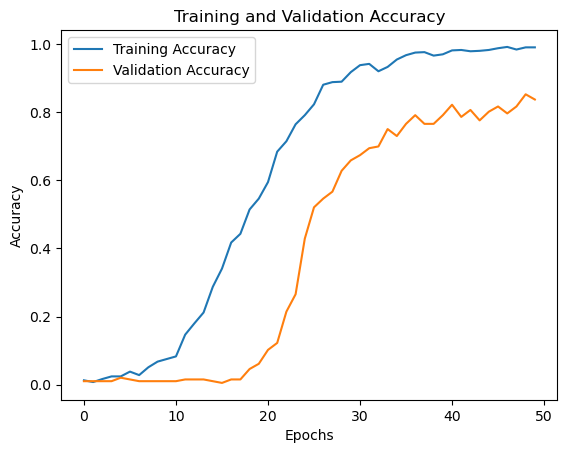

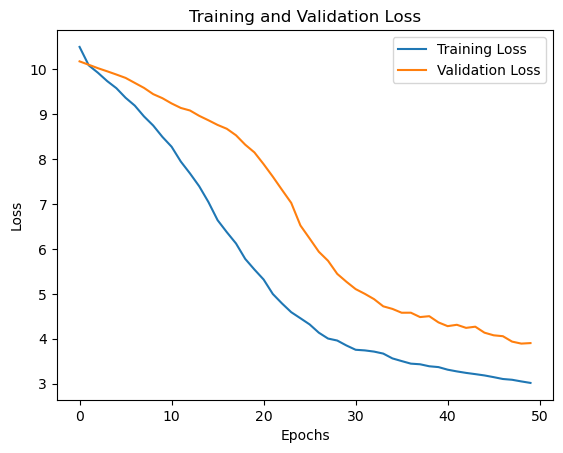

In [7]:
# Plotting training & validation accuracy
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [6]:
# Evaluate the model

val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}")
print(f"Validation Loss: {val_loss:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8579 - loss: 3.8873
Validation Accuracy: 85.20
Validation Loss: 3.8928
